# Trabajo 4: Visualización de datos con Matplotlib y Seaborn

## Análisis del dataset Superstore

En este notebook se prepara y analiza el archivo `superstore_dataset2012.csv` utilizando **Pandas**, **Matplotlib** y **Seaborn**.

Se incluyen visualizaciones univariantes, bivariantes y multivariantes, además de una figura con cuatro subplots y el guardado de una imagen.

## 1. Importar librerías

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 2. Localizar y cargar el dataset

El código prueba varias rutas para que funcione tanto en la plataforma como en Visual Studio Code.

In [ ]:
rutas_posibles = [
    Path("/workspace/superstore_dataset2012.csv"),
    Path("data/superstore_dataset2012.csv"),
    Path(
        "actividades/"
        "trabajo04_VisualizacionDatosConMatplotlibySeaborn/"
        "data/"
        "superstore_dataset2012.csv"
    ),
]

ruta_dataset = next(
    (ruta for ruta in rutas_posibles if ruta.exists()),
    None
)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró superstore_dataset2012.csv. "
        "Colócalo en la carpeta data/ del Trabajo 4."
    )

print("Dataset encontrado en:", ruta_dataset.resolve())

df = pd.read_csv(
    ruta_dataset,
    encoding="latin-1"
)

display(df.head())

Dataset encontrado en: D:\documentos\master-ciberseguridad-unir\certificaciones\python\trabajo1_ sintaxisPython\actividades\trabajo04_VisualizacionDatosConMatplotlibySeaborn\data\superstore_dataset2012.csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,1/2/2012,6/2/2012,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High
3,2828,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,FUR-CH-10001423,Furniture,Chairs,"Harbour Creations Rocking Chair, Black",192.8800,2,0.00,54.0000,19.27,High
4,6762,MX-2012-151904,1/2/2012,3/2/2012,First Class,DJ-13420,Denny Joy,Corporate,Villa Canales,Guatemala,...,OFF-PA-10003571,Office Supplies,Paper,"Enermax Cards & Envelopes, Recycled",94.0200,3,0.00,1.8600,10.73,Medium


## 3. Exploración inicial y preparación de datos

In [ ]:
print("Dimensiones del dataset:", df.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isna().sum())

Dimensiones del dataset: (4246, 24)

Columnas:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']

Tipos de datos:
Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Postal Code       float64
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: 

In [ ]:
# Función para reconocer nombres frecuentes de columnas.
def buscar_columna(dataframe, opciones):
    columnas = {
        str(col).strip().lower().replace(" ", "_").replace("-", "_"): col
        for col in dataframe.columns
    }

    for opcion in opciones:
        clave = opcion.strip().lower().replace(" ", "_").replace("-", "_")
        if clave in columnas:
            return columnas[clave]

    return None


col_ventas = buscar_columna(
    df,
    ["sales", "ventas", "venta"]
)

col_beneficios = buscar_columna(
    df,
    ["profit", "beneficios", "beneficio"]
)

col_categoria = buscar_columna(
    df,
    ["category", "categoria", "categoría"]
)

col_segmento = buscar_columna(
    df,
    ["segment", "segmento"]
)

col_fecha_pedido = buscar_columna(
    df,
    ["order_date", "fecha_pedido", "fecha_orden"]
)

col_fecha_envio = buscar_columna(
    df,
    ["ship_date", "fecha_envio"]
)

print("Columna de ventas:", col_ventas)
print("Columna de beneficios:", col_beneficios)
print("Columna de categoría:", col_categoria)
print("Columna de segmento:", col_segmento)
print("Columna de fecha de pedido:", col_fecha_pedido)
print("Columna de fecha de envío:", col_fecha_envio)

Columna de ventas: Sales
Columna de beneficios: Profit
Columna de categoría: Category
Columna de segmento: Segment
Columna de fecha de pedido: Order Date
Columna de fecha de envío: Ship Date


In [ ]:
# Convertir fechas cuando estén disponibles.
for columna_fecha in [col_fecha_pedido, col_fecha_envio]:
    if columna_fecha is not None:
        df[columna_fecha] = pd.to_datetime(
            df[columna_fecha],
            errors="coerce"
        )

# Convertir las columnas principales a numéricas por seguridad.
for columna_numerica in [col_ventas, col_beneficios]:
    if columna_numerica is not None:
        df[columna_numerica] = pd.to_numeric(
            df[columna_numerica],
            errors="coerce"
        )

# Eliminar únicamente las filas que no tienen las variables principales.
columnas_necesarias = [
    columna
    for columna in [col_ventas, col_beneficios, col_categoria]
    if columna is not None
]

df_limpio = df.dropna(subset=columnas_necesarias).copy()

print("Filas originales:", len(df))
print("Filas después de la limpieza:", len(df_limpio))

Filas originales: 4246
Filas después de la limpieza: 4246


## 4. Gráfico univariante con Matplotlib

El histograma permite observar la distribución de las ventas.

**Conclusión:** muestra en qué rangos se concentran las operaciones y ayuda a detectar ventas muy superiores al resto.

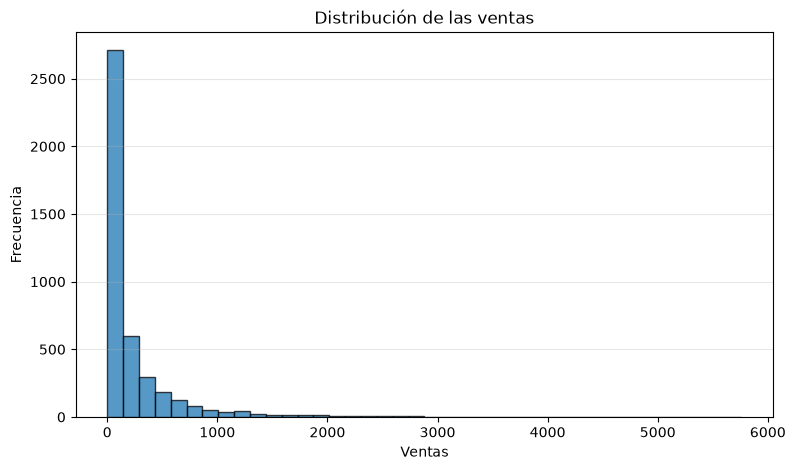

In [ ]:
if col_ventas is None:
    raise KeyError("No se encontró una columna de Ventas/Sales.")

plt.figure(figsize=(9, 5))

plt.hist(
    df_limpio[col_ventas],
    bins=40,
    alpha=0.75,
    edgecolor="black"
)

plt.title("Distribución de las ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Gráfico univariante con Seaborn

Se utiliza un boxplot para comparar la distribución de ventas entre categorías.

**Conclusión:** permite observar diferencias entre categorías y detectar valores atípicos.

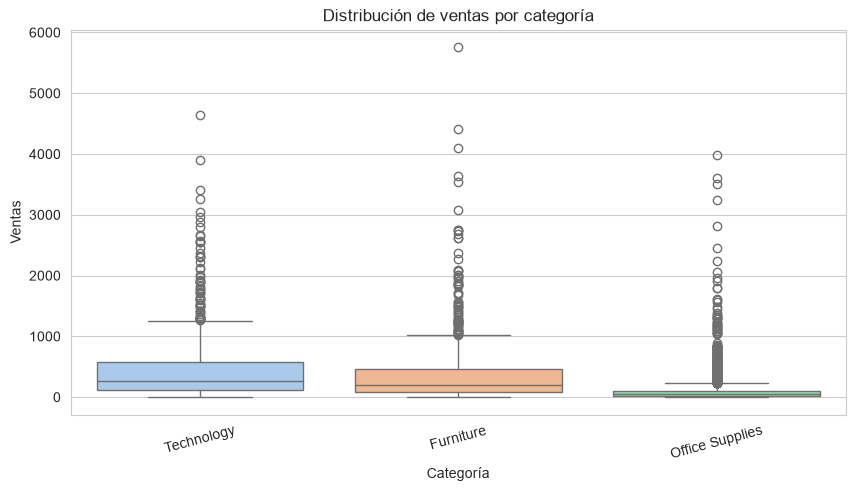

In [ ]:
if col_categoria is None:
    print("No existe una columna de categoría; se omite este gráfico.")
else:
    sns.set_style("whitegrid")

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df_limpio,
        x=col_categoria,
        y=col_ventas,
        hue=col_categoria,
        palette="pastel",
        legend=False
    )

    plt.title("Distribución de ventas por categoría")
    plt.xlabel("Categoría")
    plt.ylabel("Ventas")
    plt.xticks(rotation=15)

    plt.show()

## 6. Gráfico bivariante con Matplotlib

El gráfico de dispersión compara las ventas con los beneficios.

**Conclusión:** ayuda a determinar si un mayor volumen de ventas suele estar asociado con mayores beneficios o si existen operaciones con ventas altas y beneficios negativos.

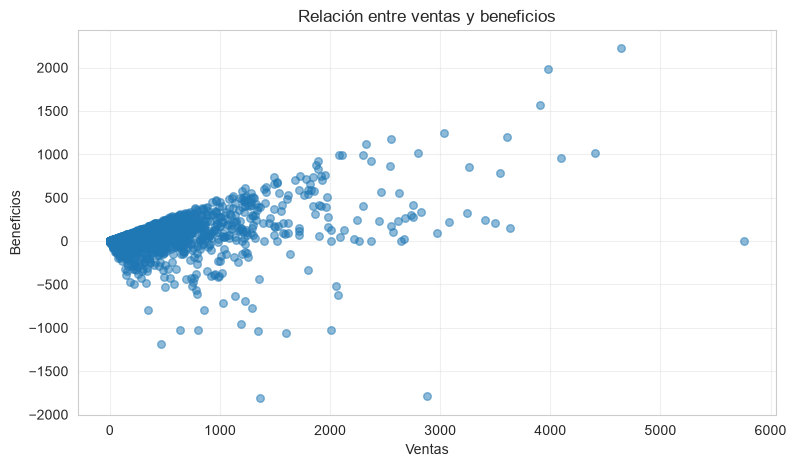

In [ ]:
if col_beneficios is None:
    print("No existe una columna de beneficios; se omite este gráfico.")
else:
    plt.figure(figsize=(9, 5))

    plt.scatter(
        df_limpio[col_ventas],
        df_limpio[col_beneficios],
        alpha=0.5,
        s=30
    )

    plt.title("Relación entre ventas y beneficios")
    plt.xlabel("Ventas")
    plt.ylabel("Beneficios")
    plt.grid(alpha=0.3)

    plt.show()

## 7. Gráfico bivariante con Seaborn

`regplot()` añade una línea de regresión para facilitar la interpretación de la tendencia entre ventas y beneficios.

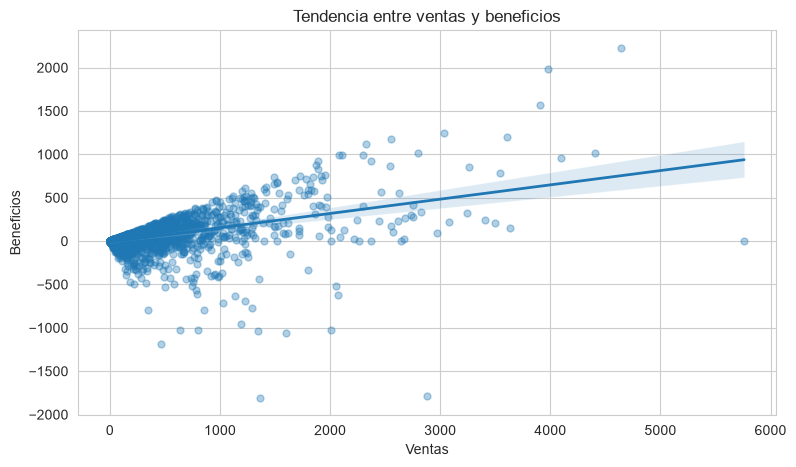

In [ ]:
if col_beneficios is None:
    print("No existe una columna de beneficios; se omite este gráfico.")
else:
    sns.set_style("whitegrid")

    plt.figure(figsize=(9, 5))

    sns.regplot(
        data=df_limpio,
        x=col_ventas,
        y=col_beneficios,
        scatter_kws={"alpha": 0.35, "s": 25},
        line_kws={"linewidth": 2}
    )

    plt.title("Tendencia entre ventas y beneficios")
    plt.xlabel("Ventas")
    plt.ylabel("Beneficios")

    plt.show()

## 8. Visualización multivariante con Matplotlib

Para cubrir explícitamente el análisis **multivariante con Matplotlib**, se representa la matriz de correlación de todas las variables numéricas utilizando únicamente `Matplotlib` con `imshow()`.

Este gráfico analiza simultáneamente varias variables y permite identificar relaciones positivas, negativas o débiles entre ellas.

**Conclusión:** los valores cercanos a `1` indican una relación positiva fuerte, los valores cercanos a `-1` una relación negativa fuerte y los valores cercanos a `0` una relación lineal débil.

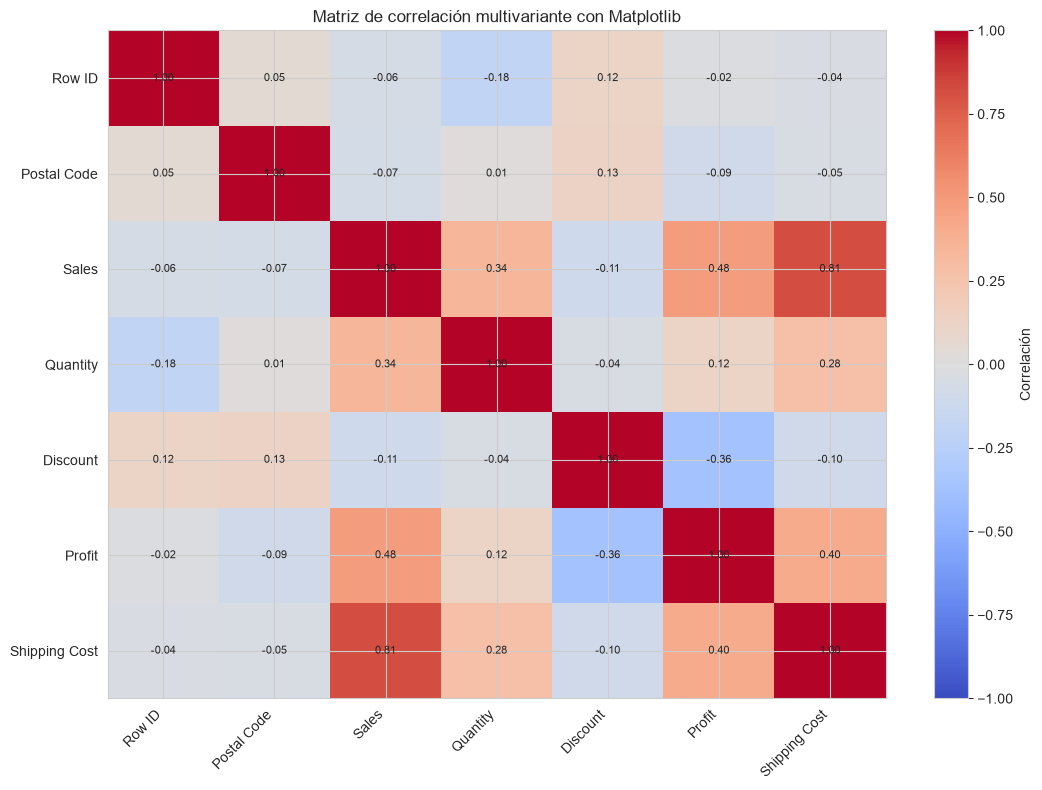

In [ ]:
# Seleccionar todas las columnas numéricas disponibles.
columnas_numericas = df_limpio.select_dtypes(
    include="number"
).columns

correlacion_matplotlib = df_limpio[
    columnas_numericas
].corr()

# Heatmap multivariante realizado exclusivamente con Matplotlib.
fig, ax = plt.subplots(figsize=(11, 8))

imagen = ax.imshow(
    correlacion_matplotlib,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Etiquetas de filas y columnas.
ax.set_xticks(range(len(columnas_numericas)))
ax.set_yticks(range(len(columnas_numericas)))
ax.set_xticklabels(
    columnas_numericas,
    rotation=45,
    ha="right"
)
ax.set_yticklabels(columnas_numericas)

# Mostrar el valor de correlación dentro de cada celda.
for fila in range(len(columnas_numericas)):
    for columna in range(len(columnas_numericas)):
        valor = correlacion_matplotlib.iloc[
            fila,
            columna
        ]
        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(
    imagen,
    ax=ax,
    label="Correlación"
)

ax.set_title(
    "Matriz de correlación multivariante con Matplotlib"
)

fig.tight_layout()
plt.show()

## 9. Visualización multivariante con Seaborn

Se calcula una matriz de correlación utilizando las columnas numéricas del dataset y se representa mediante un heatmap.

**Conclusión:** las correlaciones cercanas a `1` indican relación positiva fuerte, las cercanas a `-1` relación negativa fuerte y las cercanas a `0` poca relación lineal.

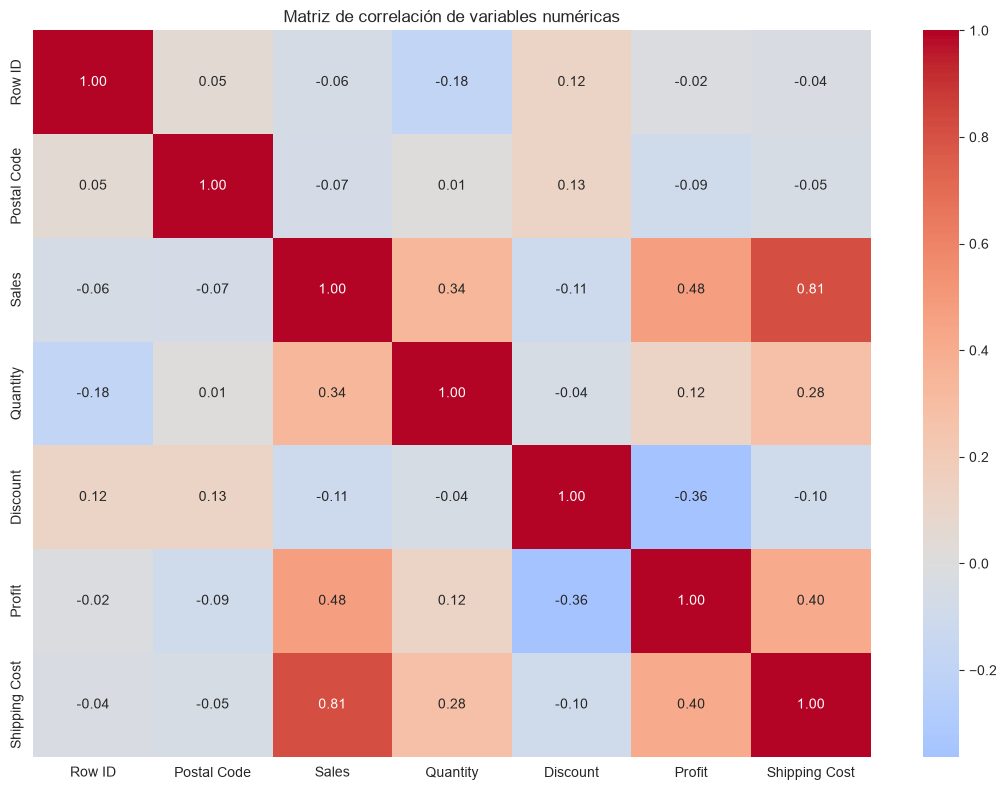

In [ ]:
columnas_numericas = df_limpio.select_dtypes(
    include="number"
).columns

correlacion = df_limpio[columnas_numericas].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

## 10. Múltiples visualizaciones mediante subplots

La siguiente figura organiza cuatro visualizaciones en una cuadrícula 2x2 y posteriormente se guarda como archivo PNG.

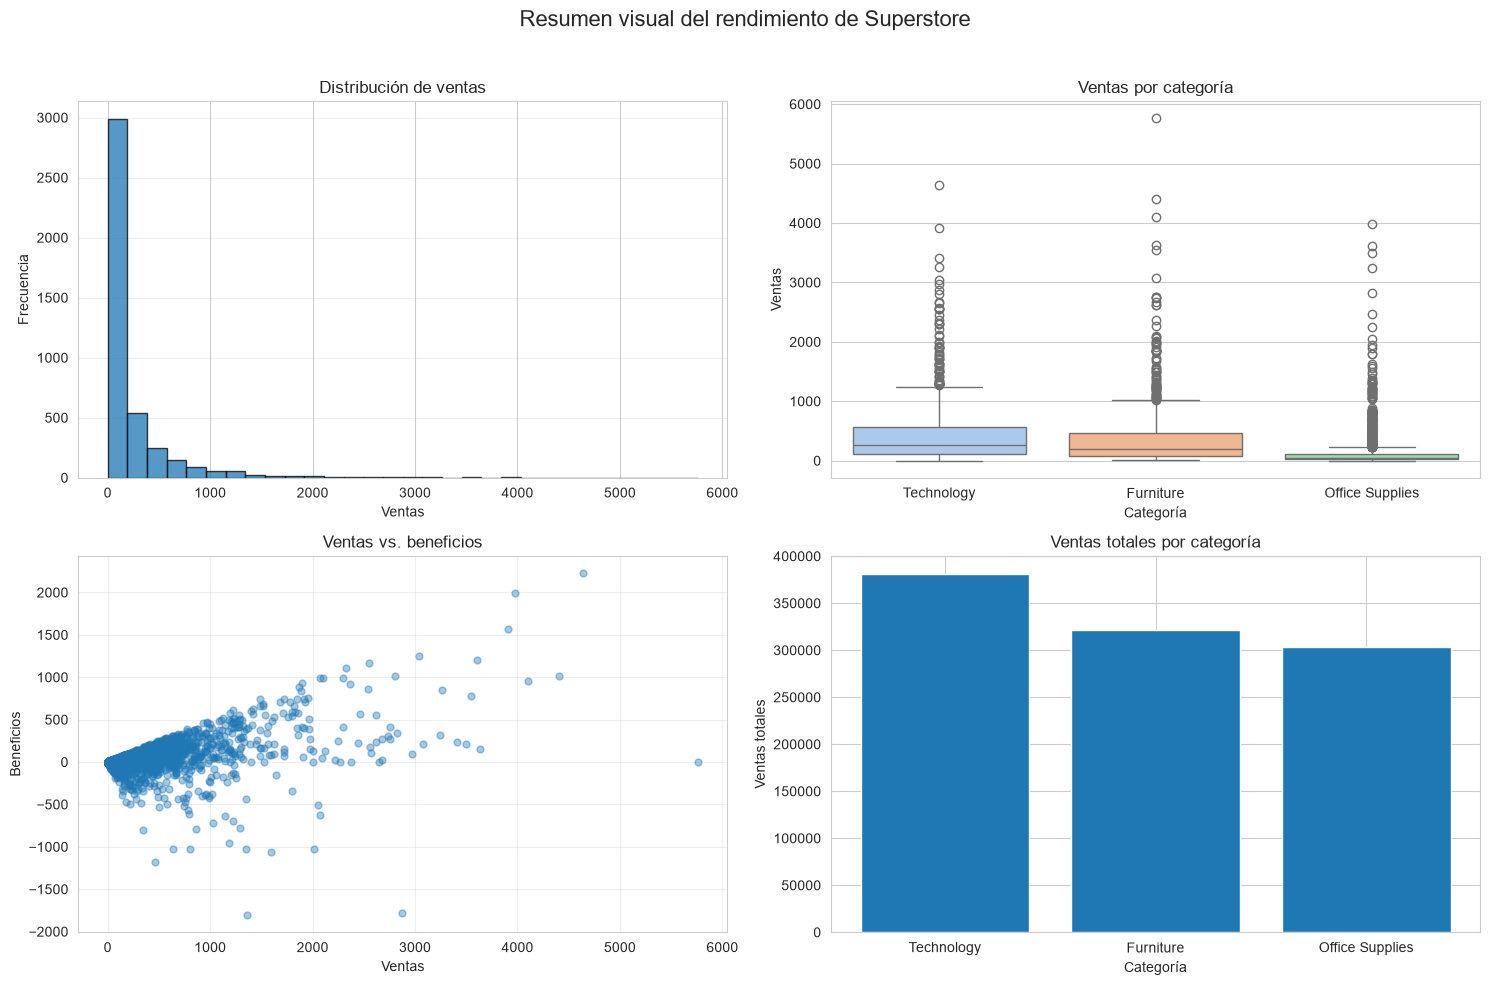

Figura guardada correctamente en: D:\documentos\master-ciberseguridad-unir\certificaciones\python\trabajo1_ sintaxisPython\actividades\trabajo04_VisualizacionDatosConMatplotlibySeaborn\actividades\trabajo04_VisualizacionDatosConMatplotlibySeaborn\resultados\visualizacion_resumen.png
¿El archivo existe?: True


In [ ]:
from tempfile import gettempdir

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# 1. Histograma de ventas con Matplotlib.
axes[0, 0].hist(
    df_limpio[col_ventas],
    bins=30,
    alpha=0.75,
    edgecolor="black"
)
axes[0, 0].set_title("Distribución de ventas")
axes[0, 0].set_xlabel("Ventas")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Boxplot de ventas por categoría con Seaborn.
if col_categoria is not None:
    sns.boxplot(
        data=df_limpio,
        x=col_categoria,
        y=col_ventas,
        hue=col_categoria,
        palette="pastel",
        legend=False,
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("Ventas por categoría")
    axes[0, 1].set_xlabel("Categoría")
    axes[0, 1].set_ylabel("Ventas")
else:
    axes[0, 1].text(
        0.5,
        0.5,
        "No hay columna de categoría",
        ha="center",
        va="center"
    )

# 3. Dispersión Ventas vs. Beneficios con Matplotlib.
if col_beneficios is not None:
    axes[1, 0].scatter(
        df_limpio[col_ventas],
        df_limpio[col_beneficios],
        alpha=0.4,
        s=25
    )
    axes[1, 0].set_title("Ventas vs. beneficios")
    axes[1, 0].set_xlabel("Ventas")
    axes[1, 0].set_ylabel("Beneficios")
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].text(
        0.5,
        0.5,
        "No hay columna de beneficios",
        ha="center",
        va="center"
    )

# 4. Ventas totales por categoría con Matplotlib.
if col_categoria is not None:
    ventas_categoria = (
        df_limpio.groupby(col_categoria)[col_ventas]
        .sum()
        .sort_values(ascending=False)
    )

    axes[1, 1].bar(
        ventas_categoria.index.astype(str),
        ventas_categoria.values
    )
    axes[1, 1].set_title("Ventas totales por categoría")
    axes[1, 1].set_xlabel("Categoría")
    axes[1, 1].set_ylabel("Ventas totales")
else:
    axes[1, 1].text(
        0.5,
        0.5,
        "No hay columna de categoría",
        ha="center",
        va="center"
    )

fig.suptitle(
    "Resumen visual del rendimiento de Superstore",
    fontsize=16
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Buscar dinámicamente la carpeta del Trabajo 4.
carpeta_trabajo = Path.cwd()

if carpeta_trabajo.name != "trabajo04_VisualizacionDatosConMatplotlibySeaborn":
    carpeta_trabajo = (
        Path.cwd()
        / "actividades"
        / "trabajo04_VisualizacionDatosConMatplotlibySeaborn"
    )

# Crear la carpeta resultados si no existe.
carpeta_resultados = carpeta_trabajo / "resultados"

carpeta_resultados.mkdir(
    parents=True,
    exist_ok=True
)

# Nombre de la imagen.
nombre_imagen = "visualizacion_resumen.png"

try:
    # Intentar guardar primero en la carpeta resultados.
    ruta_imagen = carpeta_resultados / nombre_imagen

    fig.savefig(
        ruta_imagen,
        dpi=300,
        bbox_inches="tight"
    )

except (PermissionError, OSError):
    # Si hay un problema de permisos, guardar en la carpeta temporal.
    ruta_imagen = Path(gettempdir()) / nombre_imagen

    fig.savefig(
        ruta_imagen,
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

print(
    "Figura guardada correctamente en:",
    ruta_imagen.resolve()
)

print(
    "¿El archivo existe?:",
    ruta_imagen.exists()
)

## 11. Conclusiones generales

Las visualizaciones permiten estudiar el comportamiento del dataset desde diferentes perspectivas:

- El histograma muestra la distribución general de las ventas.
- El boxplot permite comparar las ventas entre categorías y detectar valores atípicos.
- Los gráficos de dispersión permiten analizar la relación entre ventas y beneficios.
- La línea de regresión ayuda a interpretar la tendencia general entre las dos variables.
- La matriz de correlación con `Matplotlib` (`imshow`) cubre explícitamente el análisis multivariante con Matplotlib.
- El heatmap de Seaborn permite estudiar simultáneamente las relaciones entre múltiples variables numéricas.
- Los subplots ofrecen un resumen compacto del análisis y cumplen con el requisito de integrar al menos cuatro visualizaciones en una sola figura.
- La figura se guarda en el directorio actual cuando existe permiso de escritura y, en caso contrario, se guarda automáticamente en un directorio temporal para evitar errores de permisos.

La interpretación exacta de los resultados dependerá de los valores obtenidos al ejecutar el notebook con `superstore_dataset2012.csv`.